<a href="https://colab.research.google.com/github/Requiessss/DATA-science-prj/blob/main/Main_prj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd

arms_df = pd.read_csv("arms_transfers_final_clean.csv")

arms_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9741 entries, 0 to 9740
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Recipient                       9741 non-null   object 
 1   Supplier                        9741 non-null   object 
 2   Year of order                   9741 non-null   int64  
 3   Number ordered                  9656 non-null   float64
 4   Weapon designation              9741 non-null   object 
 5   Weapon description              9741 non-null   object 
 6   Deliveries in the Year Range    9741 non-null   float64
 7   Year(s) of delivery             9741 non-null   object 
 8   status                          9741 non-null   object 
 9   SIPRI TIV per unit              9741 non-null   float64
 10  SIPRI TIV for total order       9741 non-null   float64
 11  SIPRI TIV of delivered weapons  9741 non-null   float64
 12  Number ordered missing          97

In [4]:
arms_df.to_csv("arms_transfers_final_clean.csv", index=False)

In [5]:
arms_df.isna().sum()

,0
Recipient,0
Supplier,0
Year of order,0
Number ordered,85
Weapon designation,0
Weapon description,0
Deliveries in the Year Range,0
Year(s) of delivery,0
status,0
SIPRI TIV per unit,0


In [ ]:
arms_df.to_csv("us_arms_transfers_cleaned.csv", index=False)

In [9]:
#How many transfer occured each year
arms_df.groupby("Year of order").size().sort_index()

,0
Year of order,
1940,1
1945,1
1946,3
1947,4
1948,16
...,...
2021,113
2022,176
2023,155


In [11]:
#Which countires recieved the most US arms transfers
top_recipients = (
    arms_df.groupby("Recipient")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

top_recipients

,0
Recipient,
South Korea,381
Japan,361
Taiwan,356
United States,307
Israel,303
Turkiye,294
Greece,285
Thailand,277
Saudi Arabia,254


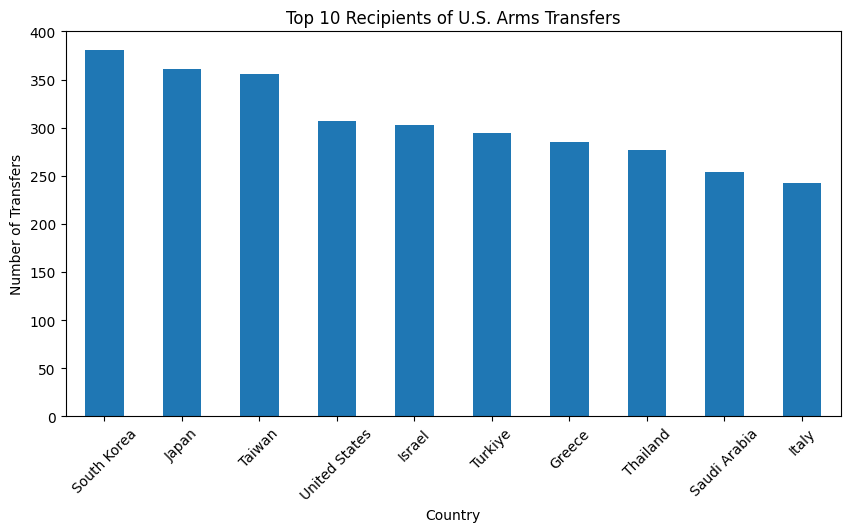

In [12]:
#Which countires recieved the most US arms transfers
import matplotlib.pyplot as plt

top_recipients.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Recipients of U.S. Arms Transfers")
plt.xlabel("Country")
plt.ylabel("Number of Transfers")
plt.xticks(rotation=45)

plt.show()

In [13]:
#which wepons cat is exported the most
arms_df['Weapon description'].value_counts().head(10)

,count
Weapon description,
armoured personnel carrier,553
transport aircraft,540
helicopter,433
light transport aircraft,422
fighter/ground-attack aircraft,416
light helicopter,385
surface-to-air missile,314
long-range air-to-air missile,285
light aircraft,283


In [14]:
#which countries receive the greatest total military value
#add note: Think of it as measuring the size and quality of the toolbox, not how skilled the carpenter is.
arms_df.groupby("Recipient")["SIPRI TIV for total order"] \
.sum() \
.sort_values(ascending=False) \
.head(20)

,SIPRI TIV for total order
Recipient,
Japan,78457.94
Saudi Arabia,59005.28
United States,54622.98
Germany,50286.28
South Korea,49200.08
Israel,43671.13
Taiwan,40969.57
United Kingdom,39647.18
Turkiye,36038.63


In [15]:
#Which weapon systems have the highest total valu
arms_df.groupby("Weapon designation")["SIPRI TIV for total order"] \
.sum() \
.sort_values(ascending=False) \
.head(10)

,SIPRI TIV for total order
Weapon designation,
F-35A Lightning-2,51425.00
F-16C,21740.94
F-104G Starfighter,20793.92
F-16C Block-50,19282.00
F-4E Phantom-2,18450.00
F-16A,17274.96
F-15 Advanced Eagle,16467.00
F-15C Eagle,15732.00
C-130H Hercules,15282.96


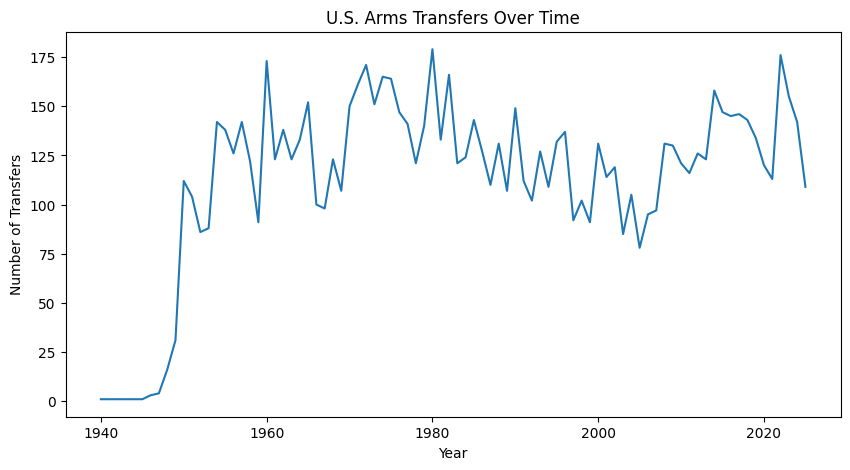

In [16]:
#How has U.S. arms transfer activity changed over time
orders_by_year = (
    arms_df.groupby("Year of order")
    .size()
)

orders_by_year.plot(figsize=(10,5))

plt.title("U.S. Arms Transfers Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Transfers")

plt.show()

In [17]:
long_term_recipients = (
    arms_df.groupby("Recipient")["Year of order"]
    .agg(["min", "max", "count", "nunique"])
    .sort_values("nunique", ascending=False)
)

long_term_recipients.head(15)

,min,max,count,nunique
Recipient,,,,
South Korea,1949,2024,381,74
Taiwan,1951,2025,356,73
Thailand,1946,2025,277,73
Japan,1951,2025,361,72
Italy,1948,2025,242,70
Greece,1949,2024,285,70
Turkiye,1949,2024,294,70
United States,1947,2025,307,69
Australia,1950,2025,211,67


In [18]:
arms_df["status"].value_counts()

,count
status,
New,6997
Second hand,2594
Second hand but modernized,150


In [19]:
import os
os.listdir()

['.config', 'arms_transfers_final_clean.csv', 'sample_data']

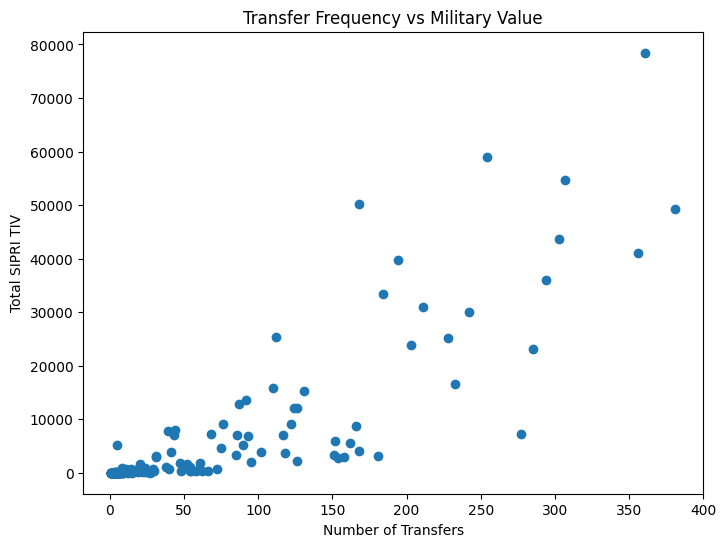

In [23]:
country_summary = (
    arms_df.groupby("Recipient")
    .agg({
        "SIPRI TIV for total order":"sum",
        "Recipient":"count"
    })
)

country_summary.columns=["Total_TIV","Transfers"]

plt.figure(figsize=(8,6))

plt.scatter(
    country_summary["Transfers"],
    country_summary["Total_TIV"]
)

plt.xlabel("Number of Transfers")
plt.ylabel("Total SIPRI TIV")
plt.title("Transfer Frequency vs Military Value")

plt.show()

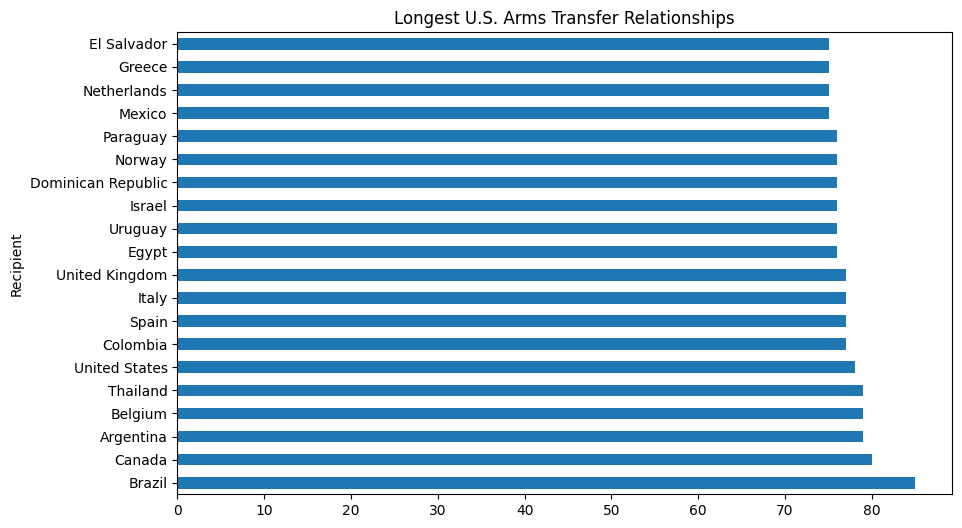

In [24]:
relationship = (
    arms_df.groupby("Recipient")["Year of order"]
    .agg(["min","max"])
)

relationship["Years"] = relationship["max"] - relationship["min"]

relationship["Years"]\
.sort_values(ascending=False)\
.head(20)\
.plot(kind="barh", figsize=(10,6))

plt.title("Longest U.S. Arms Transfer Relationships")

plt.show()

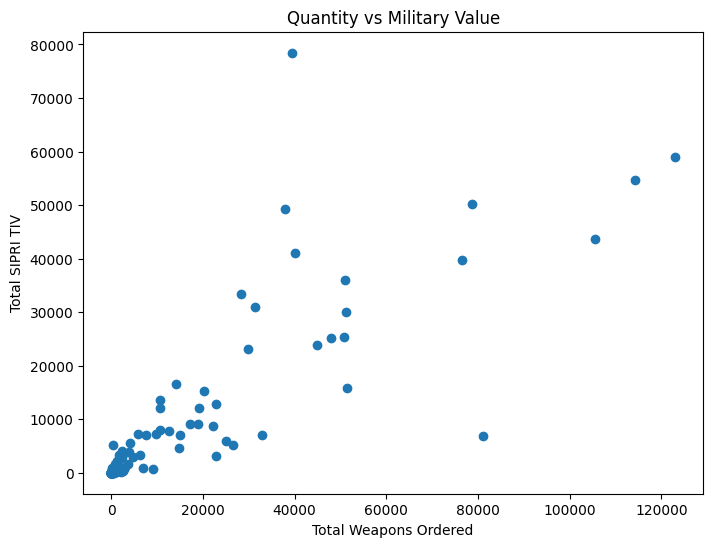

In [27]:
#fixed point value (TIV) based on how big, powerful, and advanced it is
country_summary = (
    arms_df.groupby("Recipient")
    .agg({
        "Number ordered":"sum",
        "SIPRI TIV for total order":"sum"
    })
)

plt.figure(figsize=(8,6))

plt.scatter(
    country_summary["Number ordered"],
    country_summary["SIPRI TIV for total order"]
)

plt.xlabel("Total Weapons Ordered")
plt.ylabel("Total SIPRI TIV")
plt.title("Quantity vs Military Value")

plt.show()

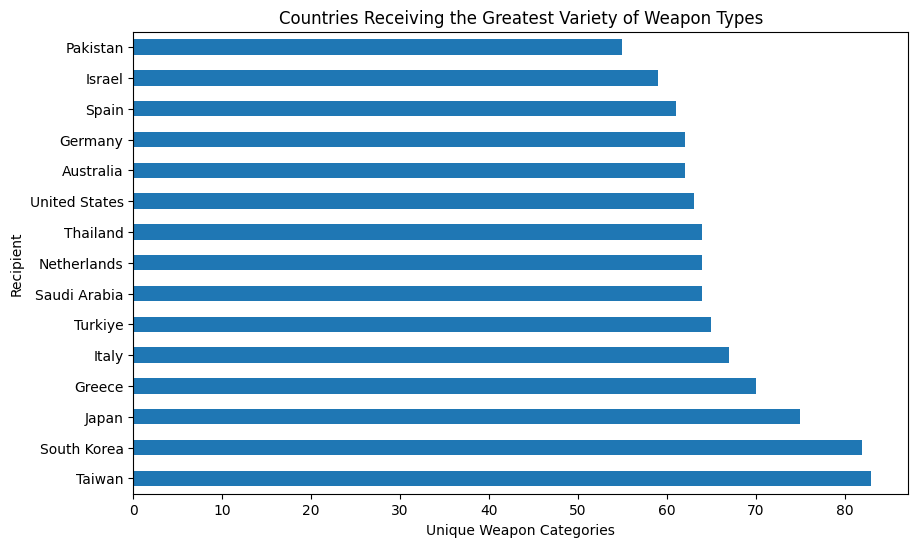

In [30]:
weapon_diversity = (
    arms_df.groupby("Recipient")["Weapon description"]
    .nunique()
    .sort_values(ascending=False)
    .head(15)
)

weapon_diversity.plot(kind="barh", figsize=(10,6))

plt.title("Countries Receiving the Greatest Variety of Weapon Types")

plt.xlabel("Unique Weapon Categories")
plt.show()

## RESERCH QUESTION ???????????: Can recipient countries be classified into distinct strategic relationship profiles based on the value, frequency, duration, and composition of U.S. arms transfers from 1940–2025?